In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import warnings
warnings.filterwarnings("ignore")


In [33]:
# Load the dataset
df = pd.read_csv("../STOCK MARKET/UPL.csv")  # Replace with your dataset file

# Select relevant features
data = df[['Close']]  # We're using only the closing price for simplicity

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)


In [34]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])   # Past 60 days as features
        y.append(data[i+time_steps])     # Next day's closing price
    return np.array(X), np.array(y)

# Create sequences
time_steps = 60  # Number of past days used for prediction
X, y = create_sequences(scaled_data, time_steps)

# Split into train-test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape X for LSTM input (samples, time steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


In [35]:
# Build the LSTM model
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(units=50, return_sequences=False),
    Dense(units=25),
    Dense(units=1)  # Final output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Model Summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))



Epoch 1/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0136 - val_loss: 0.0020
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 6.7624e-04 - val_loss: 0.0012
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 9.4554e-04 - val_loss: 8.9478e-04
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 7.6258e-04 - val_loss: 0.0014
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 5.0036e-04 - val_loss: 0.0015
Epoch 7/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 5.5283e-04 - val_loss: 6.9509e-04
Epoch 8/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - loss: 6.1817e-04 - val_loss: 6.8263e-04
Epoch 9/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 3.7309e-04 - val_loss: 0.0013
Epoch 10/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 6.8313e-04 - val_loss: 8.1155e-04
Epoch 11/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 6.1004e-04 - val_

In [37]:
# Predict on test data
predicted_prices = model.predict(X_test)

# Convert predictions back to original scale
predicted_prices = scaler.inverse_transform(predicted_prices)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


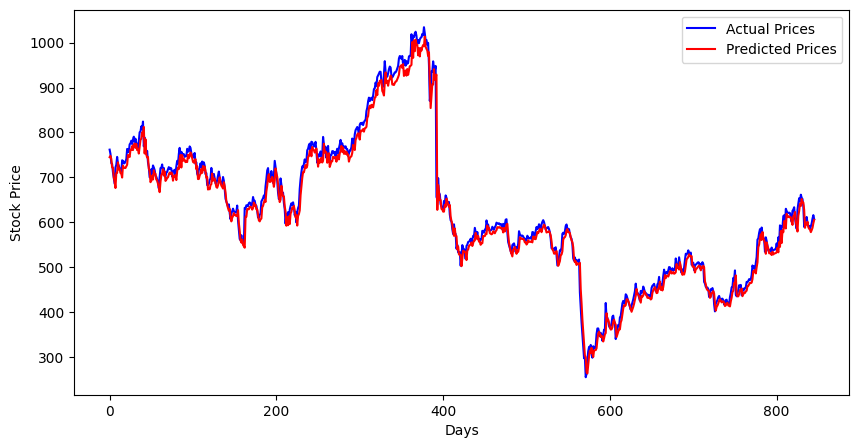

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual, label="Actual Prices", color="blue")
plt.plot(predicted_prices, label="Predicted Prices", color="red")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


In [41]:
# Get last 60 days data
last_60_days = scaled_data[-60:]
last_60_days = np.reshape(last_60_days, (1, 60, 1))  # Reshape for LSTM input

# Predict the next 7 days
future_prices = []
for i in range(10):
    next_price = model.predict(last_60_days)[0][0]
    future_prices.append(next_price)

    # Update the input sequence
    last_60_days = np.roll(last_60_days, -1, axis=1)
    last_60_days[0, -1, 0] = next_price

# Convert to original price scale
future_prices = scaler.inverse_transform(np.array(future_prices).reshape(-1, 1))

print("Predicted stock prices for next 7 days:", future_prices.flatten())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted stock prices for next 7 days: [599.0047  593.1904  586.9248  580.38776 573.72943 567.0702  560.4947
 554.0561  547.7833  541.6881 ]


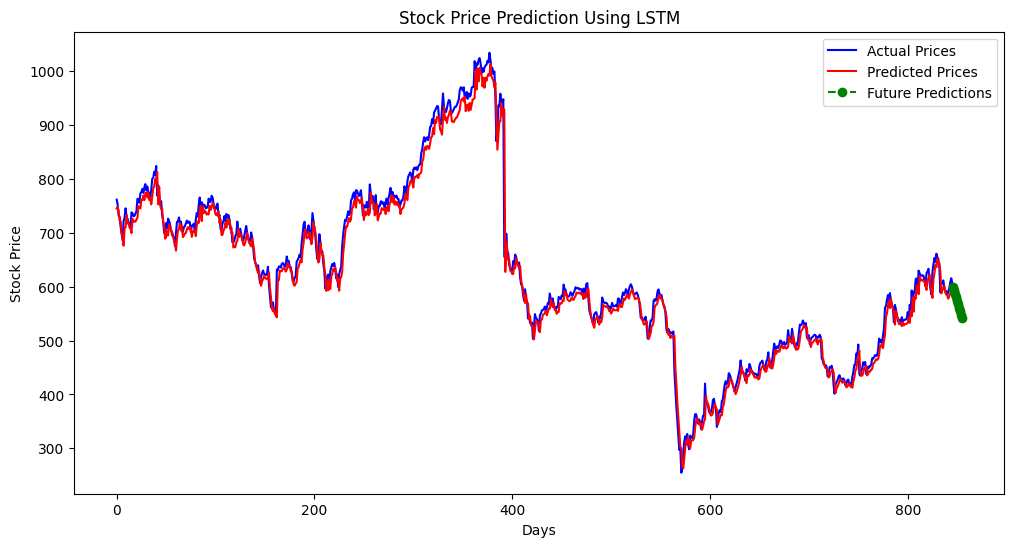

In [43]:
# Create a plot
plt.figure(figsize=(12, 6))

# Plot actual prices
plt.plot(y_test_actual, label="Actual Prices", color="blue")

# Plot predicted prices
plt.plot(predicted_prices, label="Predicted Prices", color="red")

# Plot future predicted prices (shifted to align with timeline)
future_days = list(range(len(y_test_actual), len(y_test_actual) + 10))
plt.plot(future_days, future_prices, marker='o', linestyle='dashed', label="Future Predictions", color="green")

# Labels and legend
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction Using LSTM")
plt.legend()
plt.show()
